### DS 3001: Foundations of Machine Learning
### Python for ML: Data Wrangling

Content adapted from Terence Johnson (UVA)

**Notebook Summary:** In this notebook we learn how to *wrangle* and *clean* data using Pandas. We will go over how to load in CSV files, inspect the data, rename and create variables, identify unique values and their counts for each column, thoughtfully deal with missing data, coerce data types, and filter both rows and columns based on conditional statements.

## Files Containing Data
- These are the some of the most common file formats, and what programs or languages created them:

| File Format Extension | Likely Source |
| :---: | :---:|
|.csv | Any |
|.Rda, .Rdata | R |
|.dat | SAS |
|.sav | SPSS |
|.dta | Stata |
|.mat | MATLAB |
|.xls, .xlsx | Excel |
|.json | JavaScript Object Notation|
|.parquet | Apache parquet format|
|.orc | Optimized Row Columnar, for big data |

- Unless you have a good reason, .csv is probably the most accessible format for most people

- More modern formats like parquet and orc save space by storing values in a clever way. If a column is just 0's and 1's with mostly 0's for example, they'll just track the indices where a 1 appears, rather than storing the whole column.

## Importing Necessary Packages

In [16]:
import numpy as np # Import the numpy package into your workspace
import matplotlib.pyplot as plt # Import matplotlib into your workspace
import pandas as pd  # Import the pandas package into your workspace

## Loading Data

- We're going to start with a publically available data set that has the pretrial detention of all defendants in Virginia in 2017; the codebook is in the repo, but not the data, which is too big to host on GitHub

- To load .csv data from a local file, you'll use the `.read_csv(filename)` class method:
```python
df = pd.read_csv('./data/VirginiaPretrialData2017.csv',low_memory=False)
```

- You can find the documentation for `pd.read_csv()` [here](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). The documentation for Pandas more generally can found [here](https://pandas.pydata.org/docs/index.html).

- .csv files load easily on any computer for any language, which is why we generally prefer them. If you have an Excel or Stata or SAS file, it can require some time/effort to get it loaded.

## Getting the Justice Data
- This is a fairly large dataset: 53MB
- GitHub does not want to host files that large for us (the limit is about 5MB)
- We're going to have to get it straight from the source: The Virginia Sentencing Commission
- The website where it lives is: http://www.vcsc.virginia.gov/pretrialdataproject2017.html
- To bring it into our workspace, we'll just use Pandas to go get it

In [17]:
# Define the url as a variable
url = 'http://www.vcsc.virginia.gov/pretrialdataproject/October%202017%20Cohort_Virginia%20Pretrial%20Data%20Project_Deidentified%20FINAL%20Update_10272021.csv'

# Create a data frame object using the pd.read_csv() function, pass the URL as the main argument
# Pandas downloads and loads the .csv file for you
df = pd.read_csv(url,low_memory=False)

## Getting Started With Data
- The most basic questions are,
  - How many observations?
  - How many variables?
  - What are the variable names?

- Every Pandas dataframe has a set of class attributes that are useful for looking at:
    - `.shape`: The number of rows and columns
    - `.columns`: The names of the columns (`print(df.columns.tolist())` will print all of them)
    - `.dtypes`: The types of the variables
    
- To get into the data, you have to look at the *codebook* and read both the definitions of the variables and what kinds of values they can take

In [18]:
print('Shape of the data (df.shape):\n', df.shape, '\n') # List the dimensions of df
print('Data Type of Each Column (df.dtype):\n', df.dtypes, '\n') # The types of the variables; `object` is a bad sign
print('Column Names (df.columns):\n', df.columns, '\n') # Column names

Shape of the data (df.shape):
 (22986, 709) 

Data Type of Each Column (df.dtype):
 InternalStudyID                                                 object
REQ_REC#                                                        object
Defendant_Sex                                                   object
Defendant_Race                                                  object
Defendant_BirthYear                                             object
                                                                 ...  
NewFelonySexualAssaultArrest_Disposition                        object
Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis        int64
CriminalHistoryRecordsReturnedorCMSRecordsFoundforIndividual    object
DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound      int64
CrimeCommission2021ReportClassificationofDefendants             object
Length: 709, dtype: object 

Column Names (df.columns):
 Index(['InternalStudyID', 'REQ_REC#', 'Defendant_Sex', 'Defendant_Race',
     

## Visually Inspecting the Dataframe (`.head()`, `.iloc[]`, `.loc[]`)

- **Visually inspect the data set**: Whenever you load a data set, you should take a look at its actual values; click on the .csv file in the file explorer panel

- A nice way to do this is use the Pandas dataframe method, `df.head()`, but if you have a lot of variables, it can be a bit unwieldy

- Jupyter has a data file viewer that represents it as a spreadsheet that can be helpful

- If you want to pull particular rows or columns, or otherwise slice the dataframe, you can use the:
  - **integer locator class method** `df.iloc[x:y,a:b]` for numeric address and
  - **locator class** `df.loc[row_labels, col_labels]` if you know the names of variables and rows that you want

In [19]:
df.head()

,InternalStudyID,REQ_REC#,Defendant_Sex,Defendant_Race,Defendant_BirthYear,Defendant_Age,Defendant_AgeGroup,Defendant_AgeatCurrentArrest,Defendant_AttorneyTypeAtCaseClosure,Defendant_IndigencyStatus,...,NewFelonySexualAssaultArrest_OffDate,NewFelonySexualAssaultArrest_ArrestDate,NewFelonySexualAssaultArrest_DaysBetweenContactEventandOffDate,NewFelonySexualAssaultArrest_DaysBetweenOffDateandArrestDate,NewFelonySexualAssaultArrest_DaysBetweenReleaseDateandOffDate,NewFelonySexualAssaultArrest_Disposition,Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis,CriminalHistoryRecordsReturnedorCMSRecordsFoundforIndividual,DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound,CrimeCommission2021ReportClassificationofDefendants
0,ADI00001,1,M,W,1986,31,3,31,99,99,...,,,,999,999,,4,1,0,Defendant could not be classified or tracked d...
1,ADI00007,3,M,B,1956,60,6,60,9,9,...,,,,999,999,,5,1,1,Defendant Detained Entire Pre-Trial Period_Und...
2,ADI00008,4,M,W,1990,27,3,27,9,9,...,,,,999,999,,5,1,1,Defendant Detained Entire Pre-Trial Period_Und...
3,CDI00036,6,M,B,1989,27,3,27,0,0,...,,,,999,999,,5,1,1,Defendant Detained Entire Pre-Trial Period_Und...
4,CDI00038,7,F,W,1988,28,3,28,0,0,...,,,,999,999,,0,1,1,New criminal offense punishable by incarcerati...


In [20]:
# Using the df.iloc function to use the numerical index
print(df.iloc[0:5,0:5],'\n') # Show the zero-th to fourth rows/zero-th to fourth columns


  InternalStudyID REQ_REC# Defendant_Sex Defendant_Race Defendant_BirthYear
0        ADI00001        1             M              W                1986
1        ADI00007        3             M              B                1956
2        ADI00008        4             M              W                1990
3        CDI00036        6             M              B                1989
4        CDI00038        7             F              W                1988 



In [21]:
# using the df.loc function to use the named indices of the rows and columns
print(df.loc[0:5,('Defendant_Sex','Defendant_Race')],'\n') # Show rows 0:5 of Sex and Race

  Defendant_Sex Defendant_Race
0             M              W
1             M              B
2             M              W
3             M              B
4             F              W
5             M              B 



## Renaming and Creating Variables
- Variable names are often too verbose: `BondAmountAtInitialContact`, `Defendant_IndigencyStatus`, and `CaseType_MostSerChargeinContactEvent_regardlessofFinalDisp` -- you're going to have to type these things dozens or hundreds of times

- To rename a variable, you can use `df = df.rename(columns = {oldName:newName})` (be careful to pass strings)

- To create a variable, you supply the new name as a string, as if you are indexing, `df[varName]=expression`

In [22]:
## Renaming a variable

# Create a dicionary that maps the current column names to your
# new column names
new_column_names = {
  'BondAmountAtInitialContact':'bond',
  'Defendant_IndigencyStatus':'is_poor',
  'CaseType_MostSerChargeinContactEvent_regardlessofFinalDisp':'case_type',
  'WhetherDefendantWasReleasedPretrial':'released'
}

# Use the dictionary as input to df.rename() to map the old column names to new
df = df.rename(columns = new_column_names)

# View that our new column names are there
print('Bond is in the columns?:', 'bond' in df.columns)
print('BondAmountAtInitialContact is in the columns?:', 'BondAmountAtInitialContact' in df.columns)

Bond is in the columns?: True
BondAmountAtInitialContact is in the columns?: False


In [23]:
## Creating a New Variable

# Creating a new variable called age without replacing Defendant_Age
df['age'] = df['Defendant_Age']

print('age is in the columns?:', 'age' in df.columns)
print('Defendant_Age is in the columns?:', 'Defendant_Age' in df.columns)

age is in the columns?: True
Defendant_Age is in the columns?: True


## *Student Exercise*

- The shark data come from the following source: [Global Shark Attack File](https://www.sharkattackfile.net/incidentlog.htm)
- There's not a perfect codebook, but we're going to work with the data for the exercises in this notebook.
- The shark data look bad, but almost *all* real data that haven't already been cleaned look bad

1. Load the shark data, `sharks.csv`, from the data folder

In [ ]:
# Answer Here
# Load the shark data
# Note: encoding='latin-1' is often needed for this dataset due to special characters
# from google.colab import drive
# drive.mount('/content/drive')

# !ls '/content/drive/MyDrive/data'

# df_sharks = pd.read_csv('/content/drive/MyDrive/data/sharks.csv', encoding='latin-1')

ModuleNotFoundError: No module named 'google'

2. What are the dimensions of the data? What are the data types of the variables?

In [ ]:
# Answer Here
print('Dimensions:', df_sharks.shape)
print('Data Types:\n', df_sharks.dtypes)

Dimensions: (6462, 257)
Data Types:
 index             int64
Case Number      object
Date             object
Year            float64
Type             object
                 ...   
Unnamed: 251    float64
Unnamed: 252    float64
Unnamed: 253    float64
Unnamed: 254    float64
Unnamed: 255    float64
Length: 257, dtype: object


3. What variables look interesting? (Answer in markdown cell)

3. Use `.head()`, `.iloc[]` and `.loc[]` to look at some variables or rows

In [ ]:
# Answer Here
# Visually inspect
display(df_sharks.head())
display(df_sharks.iloc[0:5, 0:5])

,index,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,...,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254,Unnamed: 255
0,0,2020.02.05,05-Feb-2020,2020.0,Unprovoked,USA,Maui,NaN,Stand-Up Paddle boarding,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2020.01.30.R,Reported 30-Jan-2020,2020.0,Provoked,BAHAMAS,Exumas,NaN,Floating,Ana Bruna Avila,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2020.01.17,17-Jan-2020,2020.0,Unprovoked,AUSTRALIA,New South Wales,Windang Beach,Surfing,Will Schroeter,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2020.01.16,16-Jan-2020,2020.0,Unprovoked,NEW ZEALAND,Southland,Oreti Beach,Surfing,Jordan King,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2020.01.13,13-Jan-2020,2020.0,Unprovoked,USA,North Carolina,"Rodanthe, Dare County",Surfing,Samuel Horne,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,index,Case Number,Date,Year,Type
0,0,2020.02.05,05-Feb-2020,2020.0,Unprovoked
1,1,2020.01.30.R,Reported 30-Jan-2020,2020.0,Provoked
2,2,2020.01.17,17-Jan-2020,2020.0,Unprovoked
3,3,2020.01.16,16-Jan-2020,2020.0,Unprovoked
4,4,2020.01.13,13-Jan-2020,2020.0,Unprovoked


4. Rename the `Fatal (Y/N)` to `fatal`

In [ ]:
# Answer Here
# Rename 'Fatal (Y/N)' to 'fatal'
df_sharks = df_sharks.rename(columns={'Fatal (Y/N)': 'fatal'})
print('Columns:', df_sharks.columns.tolist())

Columns: ['index', 'Case Number', 'Date', 'Year', 'Type', 'Country', 'Area', 'Location', 'Activity', 'Name', 'Unnamed: 9', 'Age', 'Injury', 'fatal', 'Time', 'Species ', 'Investigator or Source', 'pdf', 'href formula', 'href', 'Case Number.1', 'Case Number.2', 'original order', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'Unnamed: 66', 'Unnamed: 67', 'Unnamed: 68', 'Unnamed: 69', 'U

5. Should any variables be dropped? What's the most efficient way to do (Answer in markdown cell)

## Basic Taxomony of Variables

- **Numeric variable:**
  - Takes real number values like -1 or 5.125
  - Has units, so magnitudes can at least be compared
  - Examples: Temperature (in Fahrenheit), Salary (in dollars), Weight (thousands of pounds), Counts (numbers of students)

- **Categorical variable:**
  - A finite number of distinct categories the variable might take
  - Examples: Enrolled in College/University or Not, Alive/Dead, Animal Species, Make of a Car)
  - *Note:* There are categorical *variables* that take numeric *values*, but their units are meaningless (e.g. Zip Code, Area Code, Likert Scale)

- There are times where the appropriate thing to do is model a numeric as a categorical (e.g. grade levels in school are ordered...?)

- When a categorical variable takes binary values (e.g. alive/dead), we typically represent it with a **dummy variable** which takes the numeric value 0 or 1 (e.g. `alive == 1`, `dead == 0`)

## Unique Values, Frequency Tables, Histograms

- Looking at a column of numbers can often be unproductive, especially if there are many observations.

- The best tools to automate your understanding of a variable are:
    - `df[var].unique()`: Provides a list of the unique values occuring for that variable
    - `df[var].value_counts()`: Tabulates the number of times each unique value occurs
    - `df[var].hist()`: Plots the value counts as a bar graph

- `.unique()` is, in particular, extremely useful for learning how dirty the data is

*View the `Defendent_Sex` Variable*

In [ ]:
# Creating a new variable called sex that is the same as the 'Defendant_Sex' column
df['sex'] = df['Defendant_Sex']

# Creating a variable var with the column of interest so we do not need to
# replace it, also makes the following code more reproducible so we only need
# to change the variable name here
var = 'sex'

Unique values for sex:
 ['M' 'F' 'n' ' '] 

Value Counts for sex:
 sex
M    16587
F     6396
n        2
         1
Name: count, dtype: int64 

Histogram for sex:
 Axes(0.125,0.11;0.775x0.77) 



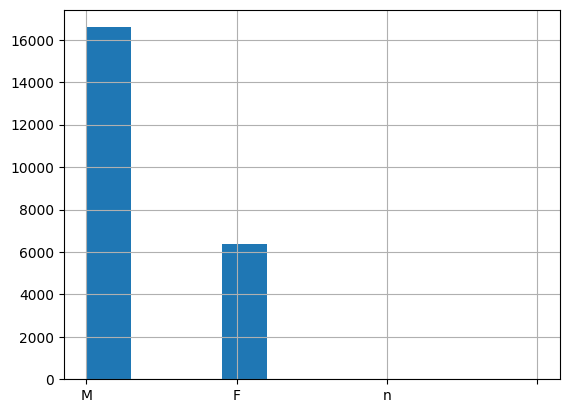

In [ ]:
# Viewing the unique values, value counts, and histogram
print(f'Unique values for {var}:\n', df[var].unique(),'\n') # 'n' is not listed in the codebook
print(f'Value Counts for {var}:\n', df[var].value_counts(), '\n') # Gather the value counts
print(f'Histogram for {var}:\n', df[var].hist(), '\n') # About 72% of observations are male

*View the `is_poor` Variable*

Unique values for is_poor:
 [99  9  0  1] 

Value Counts for is_poor:
 is_poor
0     11500
1     10465
9       747
99      274
Name: count, dtype: int64 

Histogram for is_poor:
 Axes(0.125,0.11;0.775x0.77) 



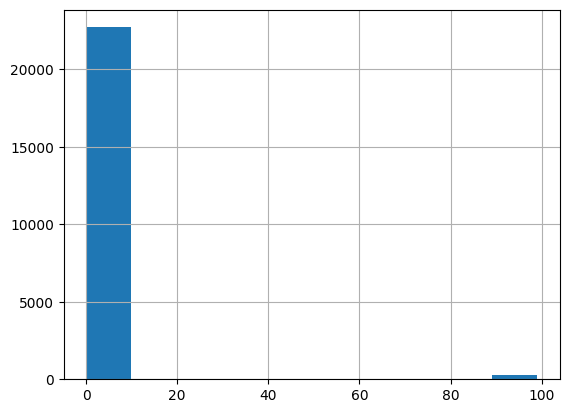

In [ ]:
# Viewing a new variable 'is_poor'
var = 'is_poor' # A dummy variable, meaning it is encoded as either 0 or 1

# Same code as the previous step

# Notice the encoding is messed up, the values should only be 0 or 1 but there's also 99 and 9
print(f'Unique values for {var}:\n', df[var].unique(),'\n')

# Look at the 9 and 99: They've encoded missing variables as both 9 and 99
print(f'Value Counts for {var}:\n', df[var].value_counts(), '\n')

# What is "bad" about this plot?
print(f'Histogram for {var}:\n', df[var].hist(), '\n')

*View the `age` Variable*

Unique values for age:
 ['31' '60' '27' '28' '39' '35' '18' '21' '66' '25' '38' '22' '40' '48'
 '34' '37' '20' '54' '46' '58' '55' '51' '24' '32' '30' '36' '26' '43'
 '56' '49' '19' '50' '52' '41' '29' '33' '42' '53' '44' '59' '45' '23'
 '63' '57' '47' '61' '78' '65' '67' '64' '62' '74' '68' '70' '69' '80'
 '75' '77' '73' '71' '72' ' ' '79' '81' '85' '100' '82' '76' '83' '93' '0'
 '99' '84' '87' '86' '92' '88'] 

Histogram for age:
 Axes(0.125,0.11;0.775x0.77) 



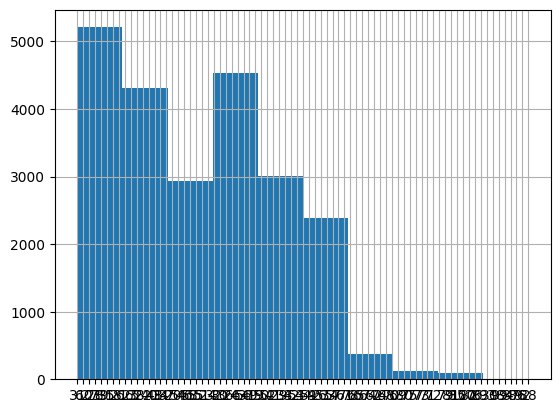

In [ ]:
# A numeric variable
var = 'age'

# Do you see some problem values?
print(f'Unique values for {var}:\n', df[var].unique(),'\n')

# This does not look very good.
print(f'Histogram for {var}:\n', df[var].hist(), '\n')

## *Student Exercise: Examining the Data*


1. What type (numeric, categorical, dummy) are each of the variables in the shark data?

In [ ]:
# Answer Here
# inspecting types
print(df_sharks.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6462 entries, 0 to 6461
Columns: 257 entries, index to Unnamed: 255
dtypes: float64(235), int64(1), object(21)
memory usage: 12.7+ MB
None


2. Use `.unique()`, `.value_counts()` and `.hist()` to take a look at variables that interest you in the shark data (Type, Activity, Year, Fatal, Age, Country are a good start)

In [ ]:
# Answer Here
# Inspecting variables of interest
for col in ['Type', 'Activity', 'Year', 'fatal', 'Age', 'Country']:
    if col in df_sharks.columns:
        print(f"--- {col} ---")
        print("Unique values (first 10):", df_sharks[col].unique()[:10])
        print("Value counts:")
        print(df_sharks[col].value_counts().head())
        print("\n")

--- Type ---
Unique values (first 10): ['Unprovoked' 'Provoked' 'Questionable' 'Watercraft' 'Unconfirmed'
 'Unverified' 'Invalid' 'Under investigation' 'Boating' 'Sea Disaster']
Value counts:
Type
Unprovoked      4716
Provoked         593
Invalid          552
Sea Disaster     239
Watercraft       142
Name: count, dtype: int64


--- Activity ---
Unique values (first 10): ['Stand-Up Paddle boarding' 'Floating' 'Surfing' 'Swimming' 'Scuba diving'
 nan 'Swimming after being swept off rocks' 'Spearfishing' 'Surf skiing'
 'Boogie boarding']
Value counts:
Activity
Surfing         1025
Swimming         932
Fishing          459
Spearfishing     350
Bathing          166
Name: count, dtype: int64


--- Year ---
Unique values (first 10): [2020. 2019. 3019. 2018. 2017.   nan 2016. 2015. 2014. 2013.]
Value counts:
Year
2015.0    143
2017.0    138
2016.0    130
2011.0    128
2014.0    127
Name: count, dtype: int64


--- fatal ---
Unique values (first 10): ['N' 'Y' nan 'F' 'M' 'UNKNOWN' '2017' 'y']
Va

3. What patterns or features of the data jump out at you? (Answer in Markdown Cell)

4. Which variables are relatively clean? Which are relatively dirty? Which do you think could be salvaged for interesting analysis? (Answer in Markdown Cell)

## Missing Data
- Data are **missing** if their values are not recorded in the dataset

- Data are typically missing in different ways: There might simply be no recorded value at all -- `... , , ...` -- in the data or it might be recorded but as a specific missing value value code like `"NA"` or `-999` or `Don't Know` or `Refusal` --- **check the codebook**

- We can't really get started on doing interesting things if the data are full of missings: Pandas will just treat the variable as an object

- **Handling missing data is the most important issue when you clean a data set**

## Why do we care about missing data?
- Abraham Wald was a statistician during WWII, working for the United States. They asked him to solve a problem. Planes would come in after a battle, hit from enemy fire:

<img src="https://github.com/DS3001/wrangling/blob/main/plane.png?raw=1" width='400' height='400' />

- Where does additional armor go to improve odds of survival?

- The absence of data can be as informative as the presence

## Other Missing Data Examples

- Other examples:
    - People who get married have higher salaries, on average
    - People who drink wine have longer lifespans, on average
    - Use of cannabis and psychedelic drugs has been linked to mental illness
    - Many places that imposed stricter pandemic protocols had worse outcomes than places that didn't (e.g. NYC vs Cville)

- In social science, every interesting problem is fundamentally a missing data issue

- "Correlation does not imply causation" isn't a vibe or slogan, it's a mathematical reality with quantitative models and tools for measuring and correcting for the bias

## `nan`'s and Pandas

- In Pandas, there are two options for representing missing values
    - The default is to treat it as an `np.nan` from the NumPy package: "Not-a-number", and its type is `float`

    - Pandas can also treat a missing value as a `None`: An empty/null object without a type or value

- We want to responsibly deal with the presence of the missing values without making bad choices that interfere with subsequent analysis

- You will often have to add the `.nan`s yourself; Pandas brings a lot of empty variable entries in as an empty string

## *Student Exercise: Detecting Missing Data*


1. What is the missing data situation in the shark data? Are some variables particularly good or bad? Are the variables reasonably clean?

In [ ]:
# Answer Here
# Missing data situation
print(df_sharks.isnull().sum())

index              0
Case Number        2
Date               1
Year               3
Type               5
                ... 
Unnamed: 251    6462
Unnamed: 252    6462
Unnamed: 253    6462
Unnamed: 254    6462
Unnamed: 255    6462
Length: 257, dtype: int64


2. Look, in particular, at `Year`, `Age`, `Type`, `Activity`, and `Species`

In [ ]:
# Answer Here
# Check specific columns for missing values
columns_to_check = ['Year', 'Age', 'Type', 'Activity', 'Species ']
# Note: 'Species ' often has a trailing space in this dataset

for col in columns_to_check:
    if col in df_sharks.columns:
        print(f"Missing in '{col}': {df_sharks[col].isnull().sum()}")
    else:
        print(f"Column '{col}' not found (checking for whitespace issues...)")
        # match stripped names
        match = [c for c in df_sharks.columns if c.strip() == col.strip()]
        if match:
            print(f"Found '{match[0]}', Missing: {df_sharks[match[0]].isnull().sum()}")

Missing in 'Year': 3
Missing in 'Age': 2871
Missing in 'Type': 5
Missing in 'Activity': 552
Missing in 'Species ': 2924


3. How did Pandas import the variables? How did it handle the missing values?

In [ ]:
# Answer Here
# Inspect how pandas imported them
# Most variables likely imported as object (string) due to dirty data (e.g. mixed numbers and strings)
print(df_sharks.dtypes)

index             int64
Case Number      object
Date             object
Year            float64
Type             object
                 ...   
Unnamed: 251    float64
Unnamed: 252    float64
Unnamed: 253    float64
Unnamed: 254    float64
Unnamed: 255    float64
Length: 257, dtype: object


## Cleaning Numeric Variables, in Detail

- Often, numeric variables include units like dollar signs or separators like commas in their values that need to be cleaned in addition to values that simply aren't recorded: Otherwise, Pandas will drop those values, which can be a big mistake

- To clean a numeric variable:
    1. **Cleaning**: Remove symbols like units (e.g. `$`) or separators (e.g. `1,000`) to preserve as much data as possible using `df[var].str.replace(pattern, replacement)`
    2. **Coercion**: Coerce the values to numeric using the Pandas method `pd.to_numeric(var)`
    3. **Sometimes, Imputation**: Often, you'll also want to **both** create a missing value dummy variable using `df[var].isnull()` and **impute** a `value` using `df[var].fillNA(value)` or `df[var].replace(np.nan,value)` to the missing values

Before coercion: 
 count     22986
unique       77
top          27
freq        939
Name: age, dtype: object 



<Axes: >

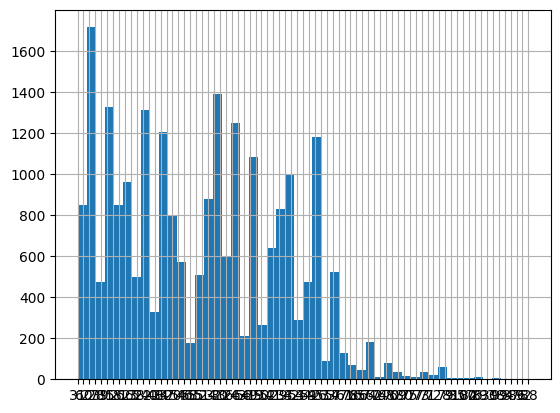

In [ ]:
# Looking at age variable
var = 'age'

# Looking at thea age variable before coercion
# Notice the age variable is not read by Pandas as a number
print('Before coercion: \n', df[var].describe(),'\n')

# Creating an initial histogram of the ages
# Look at the x-axis, why is it so crowded?
df[var].hist(bins=50)

After coercion: 
 count    22931.000000
mean        34.276525
std         12.468031
min          0.000000
25%         24.000000
50%         31.000000
75%         42.000000
max        100.000000
Name: age, dtype: float64 

Total Missings: 
 55 



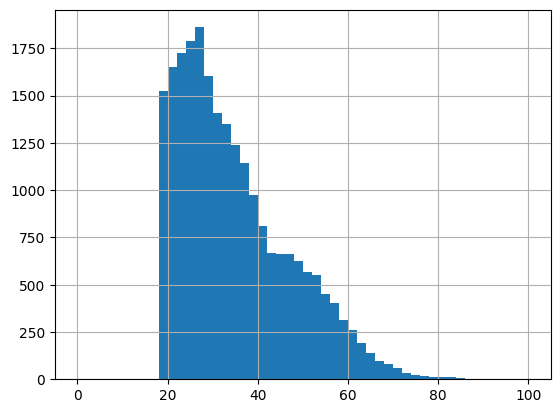

In [ ]:
## An example of type coercion

# How to coerce a variable to numeric:
df['age'] = pd.to_numeric(df['age'], errors='coerce') # Coerce the variable to numeric using the pd.to_numeric() function

# Create a missing dummy variable:
df['age_nan'] = df['age'].isnull() # Equals 1 if missing, 0 if non-null

# After coercion:
print('After coercion: \n', df['age'].describe(),'\n') # Describe the numeric variable
df['age'].hist(bins = 50) # Histogram of the variable values, notice how it looks better, why?
print('Total Missings: \n', sum(df['age_nan']),'\n') # How many missing values are there?

In [ ]:
## An Example of Imputation

# Compute the value to impute:
impute_value = df['age'].median() # Or mean, or whatever method of imputation

# Impute the median of the non-missing data:
df['age_impute'] = df['age'].fillna(impute_value)

## *Student Exercise: Numeric Handling*


1. Clean the `Age` variable for the shark data

In [ ]:
# Answer Here
# Clean Age: Coerce to numeric
df_sharks['Age'] = pd.to_numeric(df_sharks['Age'], errors='coerce')

# Check the result
print(df_sharks['Age'].describe())

# Optional: Fill NA with median if desired for analysis, or keep as NA
# df_sharks['Age'] = df_sharks['Age'].fillna(df_sharks['Age'].median())

count    3484.000000
mean       27.509759
std        14.080474
min         1.000000
25%        17.000000
50%        24.000000
75%        35.000000
max        87.000000
Name: Age, dtype: float64


## Cleaning Categorical Variables [Detailed]
- To clean a categorical variable,

    - **Option 1**: Replace each type of missing value with a new category that indicates the information about why the variable is missing, as appropriate

    - **Option 2**: Replace missings with `.nan`, and create a dummy for each qualitative type of missing value

- With the pretrial data, good examples of this are `case_type` and `is_poor`

## Multiple Missing Types
- Sometimes, data have more than one flavor of missing:

<img src="https://github.com/DS3001/wrangling/blob/main/NA_codes.jpg?raw=1" width='400' />

- In a case like this, you make sure there's a unique category for each kind of missing that might occur
- Why might this matter? Imagine a household survey question about drug use or multiple numerals for a dummy
- An example of this is (unintentionally) the `is_poor` variable


In [ ]:
# Looking at case type
var = 'case_type'
print(f'Unique values for {var} before replacement:\n', df[var].unique(), '\n') # A Categorical Example

# Replacing the empty strings with nan values
df[var] = df[var].replace(' ', np.nan) # Notice the column replacement
print(f'Value Counts for {var} after replacement:\n', df[var].value_counts(), '\n')

#Looking at the is_poor variables, a Dummy variable
var = 'is_poor'
print(f'Unique values for {var} before replacement:\n', df[var].unique(), '\n')

# Replacing the 9 and 99 values with NaN values
df[var] = df[var].replace( [9,99], np.nan) # Notice the list, allows us to do both at once
print(f'Value counts for {var} after replacement\n:', df[var].value_counts())

Unique values for case_type before replacement:
 ['F' 'M' 'S' ' ' 'I'] 

Value Counts for case_type after replacement:
 case_type
M    13616
F     7029
S     2309
I        6
Name: count, dtype: int64 

Unique values for is_poor before replacement:
 [99  9  0  1] 

Value counts for is_poor after replacement
: is_poor
0.0    11500
1.0    10465
Name: count, dtype: int64


## *Student Exercise: Categorical Handling*

1. Clean the `Type` variable as much as possible

In [ ]:
# Answer Here
# Clean Type variable
# Check unique values
print(df_sharks['Type'].unique())

# Fill missing types with 'Unknown'
df_sharks['Type'] = df_sharks['Type'].fillna('Unknown')

['Unprovoked' 'Provoked' 'Questionable' 'Watercraft' 'Unconfirmed'
 'Unverified' 'Invalid' 'Under investigation' 'Boating' 'Sea Disaster' nan
 'Boat' 'Boatomg']


2. Create a dummy variable (0/1 valued) that indicates the shark attack was fatal, with `np.nan` for values that are missing

In [ ]:
# Answer Here
# Clean 'fatal' variable to create a dummy
# 1. Standardize text (upper case, strip whitespace)
df_sharks['fatal'] = df_sharks['fatal'].astype(str).str.upper().str.strip()

# 2. Map to 0/1, treating anything not 'Y' or 'N' as NaN initially, or handling specifics
# Common bad values: 'M', '2017', 'UNKNOWN', etc.

# Create fatal_dummy
# If value is 'Y', 1. If 'N', 0. Else NaN.
df_sharks['fatal_dummy'] = df_sharks['fatal'].map({'Y': 1, 'N': 0})

print(df_sharks['fatal_dummy'].value_counts(dropna=False))

fatal_dummy
0.0    4439
1.0    1401
NaN     622
Name: count, dtype: int64


3. Which attacks were provoked? Is "not provoked" the same thing as `Unprovoked`?

In [ ]:
# Answer Here
# Check Provoked attacks
provoked_count = df_sharks[df_sharks['Type'] == 'Provoked'].shape[0]
print(f"Number of Provoked attacks: {provoked_count}")

# Compare 'Not provoked' vs 'Unprovoked' if they exist
print(df_sharks['Type'].value_counts())

Number of Provoked attacks: 593
Type
Unprovoked             4716
Provoked                593
Invalid                 552
Sea Disaster            239
Watercraft              142
Boat                    109
Boating                  92
Questionable             10
Unknown                   5
Unconfirmed               1
Unverified                1
Under investigation       1
Boatomg                   1
Name: count, dtype: int64


## When are the data "clean"?
- OK, the data are loaded: Now we want to clean them for analysis

- For the kinds of analysis we do, the data are *clean* when:
  - The data are in a single $N \times K$ matrix $X$
  - Each row $i=1,...,N$ represents a single observation
  - The observations are all of the same kind (e.g. entrepreneurs versus companies)
  - Each column $k=1,...,K$ represents a variable
  - Missing values are appropriately "handled" (converted to `.nan` where appropriate or imputed/missing-dummied when appropriate -- not still lurking as `dtype=object`'s)
  
- We might also want some other things (this updgrades "clean" to "tidy"):
  - The variable names make sense (not "NewVaCode297ViolentOff_VCCPrefix")
  - "Unnecessary" variables are removed
  - Dates are converted into numerical values, like decimal date (e.g. 2018.125) or numeric dummies
  - If the data are contained in multiple files, you end up with a single file combining all the relevant data

## Investigating Missing Data: A Case Study
- Handling the `.nan`'s is really just the first step with missing data
- For key variables, you want to eliminate as many `.nan`'s as possible through detective work
- Let's take a look at the `bond` variable: This is a crucial variable in the justice system, and most of the values are missing
- This is an example of a variable with a **long tail** of values

Description for bond:
 count      9568.000000
mean       2587.987458
std        3492.501200
min           1.000000
25%        1000.000000
50%        2000.000000
75%        3000.000000
max      160000.000000
Name: bond, dtype: float64 

Number of Missing values for bond: 13418 



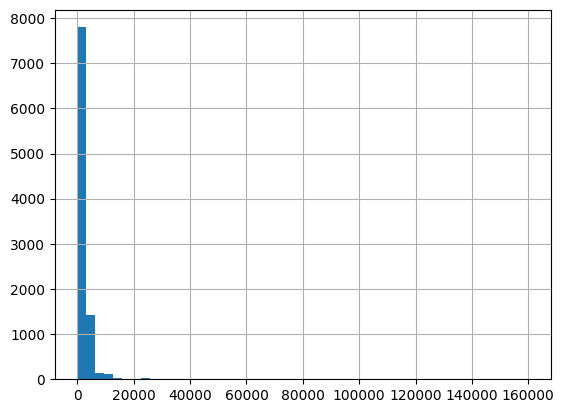

In [ ]:
# Selecting for the bond variable
var = 'bond'

# Coercing the variable to numeric
df[var] = pd.to_numeric(df[var], errors='coerce')

print(f'Description for {var}:\n', df[var].describe(),'\n') # Describe the numeric variable
df[var].hist(bins = 50) # Histogram of the variable values

df['bond_NA'] = df[var].isnull() # Create a bond missing dummy; long tail

print(f'Number of Missing values for {var}:', sum(df['bond_NA']),'\n') # How many missing values are there?


## Investigating Missing Data: Cross tabulation
- The relationships between variables are important, and we want a quick way of seeing how they relate
- **Cross tabulation** is when you break two variables into categories, and enumerate the number in each of the bins
- The function in Pandas to do this is `pd.crosstab( df[var1], df[var2] )`
- Notice this is a Pandas method (`pd.`) and not a dataframe object method (`df.`)
- This is often the first step in determining how variables co-vary with one another, before computing a statistic or using a model

In [ ]:
# Looking at the cross table between the is_poor and
# case_type values using the pd.crosstab() function
pd.crosstab(df['is_poor'], df['case_type']) # Notice the use of pd. and not df.

case_type,F,I,M,S
is_poor,,,,
0.0,2393,3,8189,905
1.0,4466,3,4748,1239


## Investigating Missing Data: A Case Study
- Let's see if we can explain *why* bond is missing so much using other variables, like whether the person was released pre-trial or the type of bond imposed.
- In the codebook, we have (notice, no category 8...):
  
![Bond Types](https://github.com/DS3001/wrangling/blob/main/bondType.png?raw=1)



In [ ]:
# Make a new variable that is true or false if bond is null or not
df['bond_NA'] = df['bond'].isnull()

# Create a cross tab between the bond NaN values and the PretrialReleaseType1 variable
# Doesn't give much insight here, no clear pattern
print(pd.crosstab(df['bond_NA'],df['PretrialReleaseType1']),'\n')

PretrialReleaseType1     0     1     2     3     4    5   6    7    8    9
bond_NA                                                                   
False                  367    39     0  5333  3015   35   0  306  388   85
True                  3434  1855  5273   447  1009  140  12  270  737  241 



In [ ]:
# Now comparing the bond NaN value and the BondTypeAtInitialContact
# Now we see   clear trend
print(pd.crosstab(df['bond_NA'],df['BondTypeAtInitialContact']),'\n')

BondTypeAtInitialContact     1     2     3     4    5     6    7  9
bond_NA                                                            
False                        0  4149  5419     0    0     0    0  0
True                      5953     0     0  1805  254  5285  117  4 



## Replacing Values
- So we want to replace certain values of the **bond** depending on values of the **bond type**
- There are (at least) two ways to do this:
    - Use `df.loc[ condition, var] = value` to replace the value of variable `var` with `value` depending on whether `condition` is true
    - Use `df[var].mask(condition,value)` to replace the value of variable `var` with `value` depending on whether `condition` is true
- We have a serious dilemma with bond category 1

## Logical Operators

- Often, we want Python to check a complex logical condition for every observation

- These are some of the most commonly used operators:
| Operator | Meaning |
| :---: | :---:|
| `and` | and |
|`or` | or |
|$==$, $!=$ | equivalence, inequivalence |
|`<=`,`<` | less-than-equal-to, less-than |
|`>=`,`>` | greater-than-equal-to, greater-than |
| `in`, `not in`| set membership, set non-membership |

- For example, we'll want to determine the observations for which `df['is_poor'] == (9 or 99)`

Axes(0.125,0.11;0.775x0.77) 

Description of Bond Variable After replacement:
 count     16912.000000
mean       1464.159413
std        2923.362046
min           0.000000
25%           0.000000
50%        1000.000000
75%        2500.000000
max      160000.000000
Name: bond, dtype: float64 

bond_NA vs BondTypeAtInitialContact crosstab:
 BondTypeAtInitialContact     1     2     3     4    5     6    7  9
bond_NA                                                            
False                        0  4149  5419  1805  254  5285    0  0
True                      5953     0     0     0    0     0  117  4 



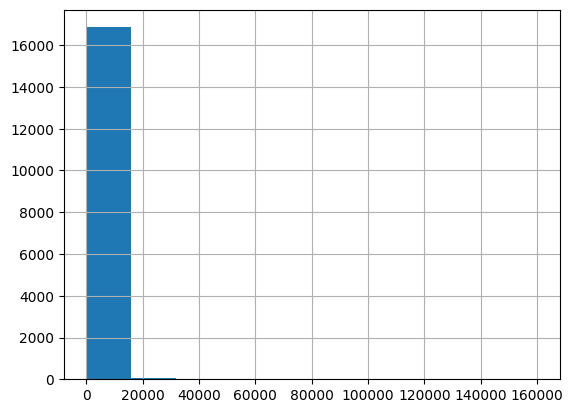

In [ ]:
## For each bond type, replace the missings

# df.loc[ df['BondTypeAtInitialContact'] == 9, 'bond'] = np.nan # Missing
# df.loc[ df['BondTypeAtInitialContact'] == 7, 'bond'] = np.nan # Unknown

# Code strategy 1: .loc
df.loc[ df['BondTypeAtInitialContact'] == 4, 'bond'] = 0 # No bond posted
df.loc[ df['BondTypeAtInitialContact'] == 5, 'bond'] = 0 # No bond posted
df.loc[ df['BondTypeAtInitialContact'] == 6, 'bond'] = 0 # No bond posted

# Code Strategy 2: .mask method
df['held_wo_bail'] = (df['BondTypeAtInitialContact'] == 1) # Create a held-without-bail dummy
df['bond'].mask(df['BondTypeAtInitialContact'] == 1 , np.nan ) # Held without bail. Nan or Inf?

# Look at the bond variable after replacement
print(df['bond'].hist(), '\n')
print('Description of Bond Variable After replacement:\n', df['bond'].describe(), '\n')

# Create an updated value for the bond_NA now that we replaced values of bond
df['bond_NA'] = df['bond'].isnull()
print('bond_NA vs BondTypeAtInitialContact crosstab:\n', pd.crosstab(df['bond_NA'],df['BondTypeAtInitialContact']),'\n')


## Investigating Missing Data: A Case Study

- Notice how we handled the "held without bail issue" (1): There is a lot of nuance here

- At this point, I'd drop categories 7 and 9, and leave the missing bond values as "held without bail" (1)

- You might be thinking, "He is really into analyzing bonds!"

- Not exactly: Cleaning data sets requires some detective work, that's what we're illustrating

- The cleaner your data are, the stronger the **signal** becomes relative to the **noise**, reducing *attenuation* of your findings

- It requires your full cognitive attention, or your results will be garbage that makes everyone less informed, knowledgeable, and productive ("**Garbage in, garbage out (GIGO)**")

- What are the **consequences for society** if you do a garbage analysis of bonds and sentencing?
  - Ex. What if we want to predict bond value for a case but we did not do our due dillegence with the data before training?

- We can't get this deeply into every variable in the data, but we must do it for the key ones for our analysis

- So how do we continue cleaning up the `bond` variable?

## *Student Exercise*

1. Cross tabulate the cleaned `Type` and `fatal` variables

In [ ]:
# Answer Here
# Cross tabulate Type and fatal_dummy
pd.crosstab(df_sharks['Type'], df_sharks['fatal_dummy'])

fatal_dummy,0.0,1.0
Type,,
Boat,105,2
Boating,92,0
Boatomg,1,0
Invalid,17,8
Provoked,566,19
Questionable,6,2
Sea Disaster,66,168
Under investigation,1,0
Unknown,1,2


2. Clean the `Type` variable up a bit by creating a new variable and consolidating the values into a smaller number of categories by replacing values

In [ ]:
# Answer Here
# Consolidate Type values
# Example: Group 'Boating' and 'Boat' -> 'Boat'
replacement_map = {
    'Boating': 'Boat',
    'Sea Disaster': 'Disaster',
    'Invalid': 'Unknown',
    'Questionable': 'Unknown'
}

df_sharks['Type_Clean'] = df_sharks['Type'].replace(replacement_map)
print(df_sharks['Type_Clean'].value_counts())

Type_Clean
Unprovoked             4716
Provoked                593
Unknown                 567
Disaster                239
Boat                    201
Watercraft              142
Unverified                1
Unconfirmed               1
Under investigation       1
Boatomg                   1
Name: count, dtype: int64


3.  Cross tab your new variable and `fatal`

In [ ]:
# Answer Here
# Cross tabulate new variable and fatal
pd.crosstab(df_sharks['Type_Clean'], df_sharks['fatal_dummy'])

fatal_dummy,0.0,1.0
Type_Clean,,
Boat,197,2
Boatomg,1,0
Disaster,66,168
Provoked,566,19
Under investigation,1,0
Unknown,24,12
Unprovoked,3459,1191
Unverified,1,0
Watercraft,124,9


4. Are provoked attacks typically fatal? Which types of attack are most likely to be fatal?

In [ ]:
# Answer Here
# Check fatality rate by type
fatality_by_type = df_sharks.groupby('Type_Clean')['fatal_dummy'].mean()
print(fatality_by_type.sort_values(ascending=False))

Type_Clean
Disaster               0.717949
Unknown                0.333333
Unprovoked             0.256129
Watercraft             0.067669
Provoked               0.032479
Boat                   0.010050
Boatomg                0.000000
Under investigation    0.000000
Unverified             0.000000
Unconfirmed                 NaN
Name: fatal_dummy, dtype: float64


5. What does this mean?

6. How does this exercise make you feel about sharks?

## Selecting Subsets of the Observations (Row Filtering)
- We often want to focus only on a subset of the observations, like defendants accused of a felony
- We can **filter** on a conditional/Boolean statement, selecting the rows that get a 1 and discarding those that get a zero
- This creates a new dataframe, focused just on what we're interested in: `df['case_type']=='F'`
- For example, in the case of felonies, we can create a new dataframe: `df_felony = df[ df['case_type']=='F' ]`In general, the synattax is
 `new_df = df[ conditional ]`

In [ ]:
# Looking at the value counts for the case type
print('How many charges of each type?:\n', df['case_type'].value_counts(), '\n') # How many charges of each type?

# Create a condition that is True if a Felony and False otherwise
conditional =  (df['case_type']=='F')

# Print the value counts for the conditional variable we just made
print('Value counts for the conditional variable we created:\n', conditional.value_counts(), '\n')

# Create a new dataframe that only has cases that are felonies
df_felony = df[ conditional ]

# Look at the dimensions of the orignal and new dataframes,
# Notice how many rows the new data frame
print('Old dataframe: ', df.shape, '\n', 'New dataframe: ', df_felony.shape)

How many charges of each type?:
 case_type
M    13616
F     7029
S     2309
I        6
Name: count, dtype: int64 

Value counts for the conditional variable we created:
 case_type
False    15957
True      7029
Name: count, dtype: int64 

Old dataframe:  (22986, 715) 
 New dataframe:  (7029, 715)


## Selecting Subsets of the Variables (Column Filtering)
- Suppose you only have a few variables you're actually interested in, or you might not want to release some sensitive data like names or phone numbers
- You can use `new_df = df.filter( list )` to keep a specific set of variables in the list `list = [var1, var2, ..., varN]`
- You can use `new_df = df.drop( list, axis=1 )` to drop a specific set of variables in the list `list = [var1, var2, ..., varN]`
- For example, we might want only the demographic data, `list = ['Defendant_Age', 'Defendant_Sex', 'Defendant_Race']`... or we might want to hide those variables for privacy reasons

In [ ]:
# Creating a list of the column names we want to keep
column_list = ['Defendant_Age', 'Defendant_Sex', 'Defendant_Race']

# Using df.filter to select only the variables in our list
new_df = df.filter(column_list)

# Look at the columns and shape of th. new data frame
print('New DF Columns When Filtering:\n', new_df.columns, '\n')
print('New DF Shape When Filtering:\n', new_df.shape, '\n')

# Instead of keeping the columns in our column_list, we can drop them
# axis=1 means we are dropping columns instead of rows
new_df = df.drop(column_list,axis=1)
print('New DF Columns Afer Dropping:', new_df.columns, '\n')
print('New DF Shape After Dropping:', new_df.shape)

New DF Columns When Filtering:
 Index(['Defendant_Age', 'Defendant_Sex', 'Defendant_Race'], dtype='object') 

New DF Shape When Filtering:
 (22986, 3) 

New DF Columns Afer Dropping: Index(['InternalStudyID', 'REQ_REC#', 'Defendant_BirthYear',
       'Defendant_AgeGroup', 'Defendant_AgeatCurrentArrest',
       'Defendant_AttorneyTypeAtCaseClosure', 'is_poor',
       'Defendant_RecordedZipCode_eMag', 'Defendant_VirginiaResidencyStatus',
       'released',
       ...
       'Intertnalindicator_ReasonforExcludingFromFollowUpAnalysis',
       'CriminalHistoryRecordsReturnedorCMSRecordsFoundforIndividual',
       'DispRecordFoundforChargesinOct2017Contact_Atleast1dispfound',
       'CrimeCommission2021ReportClassificationofDefendants', 'age', 'sex',
       'age_nan', 'age_impute', 'bond_NA', 'held_wo_bail'],
      dtype='object', length=712) 

New DF Shape After Dropping: (22986, 712)


## Saving Your Cleaned Data
- Do not ever overwrite the original data file: Put it aside and save it for reproducibility purposes
- The most common format to save data in is `.csv`, and the command is almost the same as the one to read the data in: `df.to_csv(filename)`

In [ ]:
df.to_csv('pretrial_data.csv')

## *Student Exercises: Finishing Up*

- For the shark data, drop all the columns that are "Unnamed"

- Save your data as a `.csv` with a new name (not `sharks.csv`, which is the original data file; maybe `sharks_clean.csv`)

In [ ]:
# Answer Here
# Drop columns containing 'Unnamed'
df_sharks = df_sharks.loc[:, ~df_sharks.columns.str.contains('^Unnamed')]

# Save to csv
df_sharks.to_csv('sharks_clean.csv', index=False)
print("Saved cleaned data to sharks_clean.csv")

Saved cleaned data to sharks_clean.csv
